In [56]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from ultralytics import YOLO
from PIL import Image

import pandas as pd
import numpy as np
import torch

class BoundingBoxEngineering(BaseEstimator, TransformerMixin):
    def __init__(self, model = "yolo11n.pt", batch_size = 10, dsample = 128):
        super().__init__()
        self.model = YOLO(model)
        self.batch_size = batch_size
        self.dsample = (dsample, dsample)

    def fit(self, X, y=None):
        return self

    def fit_transform(self, X, y = None, **fit_params):
        return super().fit_transform(X, y, **fit_params)
    
    def transform(self, X, y=None):
        """
        For each image, run the YOLO model to detect pedestrians and traffic 
        lights. For each detected object, crop the image to a square around 
        the bounding box, resize it to 224x224, and concatenate the bounding 
        box coordinates and class label to the pixel values. Return a list 
        of frames, where each frame is a list of cropped objects.

        Args:
            X: A list of file paths to images.
            y: Ignored.

        Returns:
            A list of frames (shape = (n, 10, 224, 224, 8)), where each frame is a 
            list of cropped objects. Each cropped object is a 224x224x8 array, 
            where the first 3 channels are the pixel values, and the last 5 
            channels are the normalized bounding box coordinates and class label.
        """
        frames = []
        
        for i in range(0, len(X), self.batch_size):
            batch_paths = X[i : i + self.batch_size]
            results = self.model(batch_paths, stream=True, verbose=False)
            
            for result in results:
                image = result.orig_img[:, :, ::-1]
                W, H = image.shape[1], image.shape[0]
                frame = np.zeros((10, *self.dsample, 8), dtype=np.float32)
                
                # Move boxes to CPU immediately to free GPU space
                xyxyl = result.boxes.data.cpu().numpy()
                
                count = 0
                for x1, y1, x2, y2, _, cls in xyxyl:
                    if count >= 10:
                        break
                    if cls not in [0, 9]:
                        continue
                    
                    cls_val = (1 if cls == 0 else -1)
                    w, h = x2 - x1, y2 - y1
                    cx, cy = x1 + w / 2, y1 + h / 2
                    side = max(w, h)

                    x1 = int(max(0, cx - side / 2))
                    y1 = int(max(0, cy - side / 2))
                    x2 = int(min(W, cx + side / 2))
                    y2 = int(min(H, cy + side / 2))

                    crop = image[y1:y2, x1:x2]
                    
                    if crop.size == 0:
                        continue
                        
                    crop_resized = np.array(Image.fromarray(crop).resize(self.dsample, Image.LANCZOS)).astype(np.float32) / 255.0
                    meta = np.array([cx, cy, w, h, cls_val], dtype=np.float32) / np.array([W, H, W, H, 1], dtype=np.float32)
                    
                    frame[count] = np.concatenate([crop_resized, np.tile(meta, (*self.dsample, 1))], axis=-1)
                    count += 1
                frames.append(frame)
            torch.cuda.empty_cache()
        return np.array(frames)

In [57]:
# from preprocessors import BoundingBoxEngineering

imgs = [
    "C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/images/set01/video_0003/09850.png",
    "C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/images/set01/video_0003/00120.png",
]
bb = BoundingBoxEngineering()
results = bb.transform(imgs)

In [55]:
results.shape

(2, 10, 128, 128, 8)


0: 640x640 1 person, 1 car, 1 truck, 31.8ms
Speed: 4.3ms preprocess, 31.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


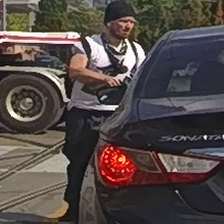

In [28]:
import numpy as np
from PIL import Image

imgs = [
    "C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/images/cropped/video_0003-04263-120.png"
]

bb = BoundingBoxEngineering()
results = bb.transform(imgs)

img = (results[0,0,:,:,:3] * 255).astype(np.uint8)

Image.fromarray(img)

In [30]:
results[:,:,:,:,:3].shape

(1, 10, 224, 224, 3)

In [46]:
import os

folder_path = r"C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/images/cropped"
imgs = [f"{folder_path}/{f}" for f in os.listdir(folder_path)[:1000]]

bb = BoundingBoxEngineering()
results = bb.transform(imgs)

# annot = pd.read_csv("C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/bboxes.csv")
files = pd.DataFrame([file.split('/')[-1].split('.')[0].split('-') for file in imgs], columns=['video', 'frame', 'content', 'id'])

OutOfMemoryError: CUDA out of memory. Tried to allocate 4.58 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 12.29 GiB is allocated by PyTorch, and 1.54 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [45]:
results.shape

(10, 10, 224, 224, 8)

In [43]:
files

,video,frame,content,id
0,video_0001,01013,pedestrian,10
1,video_0001,01013,pedestrian,9
2,video_0001,01013,traffic_light,0
3,video_0001,01013,traffic_light,1
4,video_0001,01014,pedestrian,10
5,video_0001,01014,pedestrian,9
6,video_0001,01014,traffic_light,0
7,video_0001,01014,traffic_light,1
8,video_0001,01015,pedestrian,10
9,video_0001,01015,pedestrian,9


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from typing import List, Tuple
from tqdm import tqdm

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

class ConvolutionalNeuralNetwork(nn.Module, BaseEstimator, TransformerMixin):
    def __init__(
            self,
            epoch: int = 10,
            learning_rate: float = 0.1,
            layers: List[torch.nn.Module] = [],
            criterion: str = 'CrossEntropyLoss',
            optimizer: str = 'Adam',
            batch_size: int = 100,
            minimum_change: float = 0.0,
            seed: int = 0
        ):
        super(ConvolutionalNeuralNetwork, self).__init__()

        if layers is None:
            raise ValueError("Need layers bro!")

        self.losses: List[float] = []
        self.epoch: int = epoch
        self.learning_rate: float = learning_rate
        self.layers: List[torch.nn.Module] = nn.Sequential(*layers)
        self.criterion: str = criterion
        self.optimizer: str = optimizer
        self.batch_size: int = batch_size
        self.minimum_change: float = minimum_change
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)
        self.seed: int = seed
        torch.manual_seed(self.seed)

    def forward(self, X: np.ndarray) -> np.ndarray:
        return self.layers(X)

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Extracts deep features from the image channels (0-2) and 
        concatenates them with the metadata (3-7).
        """
        # 1. Separate Images and Metadata
        # Images: (N, 224, 224, 0:3) | Metadata: (N, 224, 224, 3:8)
        images = torch.tensor(X[:, :, :, :3], dtype=torch.float32).permute(0, 3, 1, 2).to(self.device)
        
        # Extract metadata from the first pixel of each crop (since it's tiled)
        metadata = X[:, 0, 0, 3:] 

        self.eval()
        with torch.no_grad():
            # 2. Pass through the CNN layers
            features = self.forward(images)
            
            # 3. Flatten the spatial dimensions if the CNN output is still 4D
            # (Batch, Channels, 1, 1) -> (Batch, Channels)
            flat_features = torch.flatten(features, start_dim=1).cpu().numpy()

        # 4. Concatenate Smart Features with Raw Metadata
        return np.concatenate([flat_features, metadata], axis=1)

    def fit_transform(self, X: np.ndarray, y: np.array = None) -> np.ndarray:
        self.fit(X, y)
        return self.transform(X)

    def fit(self, X: np.ndarray, y: np.array) -> np.ndarray:
        y = torch.tensor(y, dtype=torch.long).to(self.device)
        X = torch.tensor(X[:, :, :, :3], dtype=torch.float32).permute(0, 3, 1, 2).to(self.device)

        criterion = getattr(torch.nn, self.criterion)()
        optimizer = getattr(torch.optim, self.optimizer)(self.parameters(), lr=self.learning_rate, weight_decay=0.001)

        dataset = torch.utils.data.TensorDataset(X, y)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        for _ in tqdm(range(self.epoch)):
            loss: float = 0.0
            for X_batch, y_batch in dataloader:
                # Forward pass
                y_batch_pred = self.forward(X_batch)
                batch_loss = criterion(y_batch_pred, y_batch)
                loss += batch_loss.item()

                # Backward and optimize
                optimizer.zero_grad()
                batch_loss.backward()
                optimizer.step()
            self.losses.append(loss / len(dataloader))
            if len(self.losses) > 1 and abs(self.losses[-2] - self.losses[-1]) <= self.minimum_change:
                break

        print("Loss: {}".format(self.losses[-1]))
        return self

In [3]:
len(list(zip(imgs, results)))

2